# Permutation Feature Importance
- Date: 9-3-2026
- This notebook is part of the ML explainability course by Soleded Galli, PhD. I highly recommend everyone take this course.

## Overview

- [Machine Learning Interpretability course](https://www.trainindata.com/p/machine-learning-interpretability)

- In this notebook, we will evaluate feature importance by permutation, using the following Python libraries:
1. Scikit-learn
2. Eli5 and
3. Feature-engine

## Imports

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.ensemble import RandomForestRegressor ## model
from sklearn.inspection import permutation_importance ## sklearn PFI function
from sklearn.model_selection import train_test_split ## train-test split

In [2]:
variables = ['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond',
             'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1',
             'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',  '1stFlrSF',
             '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
             'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
             'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars',
             'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
             '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
             'MoSold', 'YrSold', 'SalePrice']

## Load Dataset
- This loads the csv datset generated using the housing prices data from kaggle with some additional feature engineering.

In [4]:
## if using colab attach google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# load dataset
import pandas as pd

# Get the list of actual columns in the file first to avoid the ValueError
file_path = '/content/drive/MyDrive/Colab Notebooks/Machine Learning Explainability/houseprice_prep.csv'
actual_columns = pd.read_csv(file_path, nrows=0).columns.tolist()

# Filter variables to only include those present in the CSV
existing_variables = [v for v in variables if v in actual_columns]

data = pd.read_csv(file_path, usecols=existing_variables)

print(f"Missing columns: {set(variables) - set(existing_variables)}")
data.shape

Missing columns: {'YrSold'}


(1460, 33)

## Create Train-Test Split

In [7]:
# separate train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    data.drop(labels=['SalePrice'], axis=1),
    data['SalePrice'],
    test_size=0.3,
    random_state=0)

X_train.shape, X_test.shape

((1022, 32), (438, 32))

## Random Forests
- We will train a Random Forest regression model to compare the PFI differences.

In [8]:
# Train Random Forests

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=3,
    random_state=2909,)

## fit model
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=3, random_state=2909)

## R-squared interpretation
- We can see that r2 shows us that our model explains ~80% of the predictions in both the train and test set (not bad for first try).
- The r2 value (coefficient of determination) is a statistical measure that quantifies the proportion of variance in a dependent variable that can be explained by an independent variable or variables in a regression model.
  - In simple terms, it tells you how well a model's predictions match the actual data, ranging from 0 (explains none of the variance) to 1 (explains all of the variance).
  - r2 relates directly to intrinsic interpretability because it provides a direct, mathematically transparent look into a model's inner workings.


  ### What is Intrinsic Interpretability?
  - In ML and statistics, models are categorized by how we understand them:
  
    - **Intrinsic Interpretability**: The model’s structure is simple and transparent enough that you can naturally understand how it makes decisions just by looking at its math or logic (e.g., linear regression, decision trees).
    
    - **Post-hoc Interpretability**: The model is a "black box" (e.g., deep neural networks), requiring separate tools or approximations (like SHAP or LIME) to explain its decisions after it has been trained.
    
  ### Why r2 Explains Intrinsic Interpretability
  
    - **Direct Linear Relationship**: r2 is primarily used in linear models. Because these models are intrinsically interpretable, the r2 score gives you a direct, unvarnished truth about how much weight the chosen features actually hold in predicting the outcome.
    - **No "Black Box" Guesswork**: Unlike complex models where a high accuracy score doesn't tell you how the model got there, a high r2 in a linear model tells you exactly how much of the real-world variance is accounted for by your explicit equation.
    - **Clear Feature Evaluation:** In multiple linear regression, you can look at the model's coefficients alongside the r2 value. If adding a specific variable causes r2 to jump significantly, you can fundamentally trust that this specific feature has a strong, direct relationship with the target variable.

In [9]:
# R2 in train set

rf.score(X_train, y_train)

0.8084814458580268

In [10]:
# R2 in test set

rf.score(X_test, y_test)

0.780728952188919

## Tree derived feature importance
- Before looking at PFI, we can look at the Random Forest regressor tree derived feature importance.
- This is the default intrinsic derived or global feature importance that are derived from a Random Forest model.

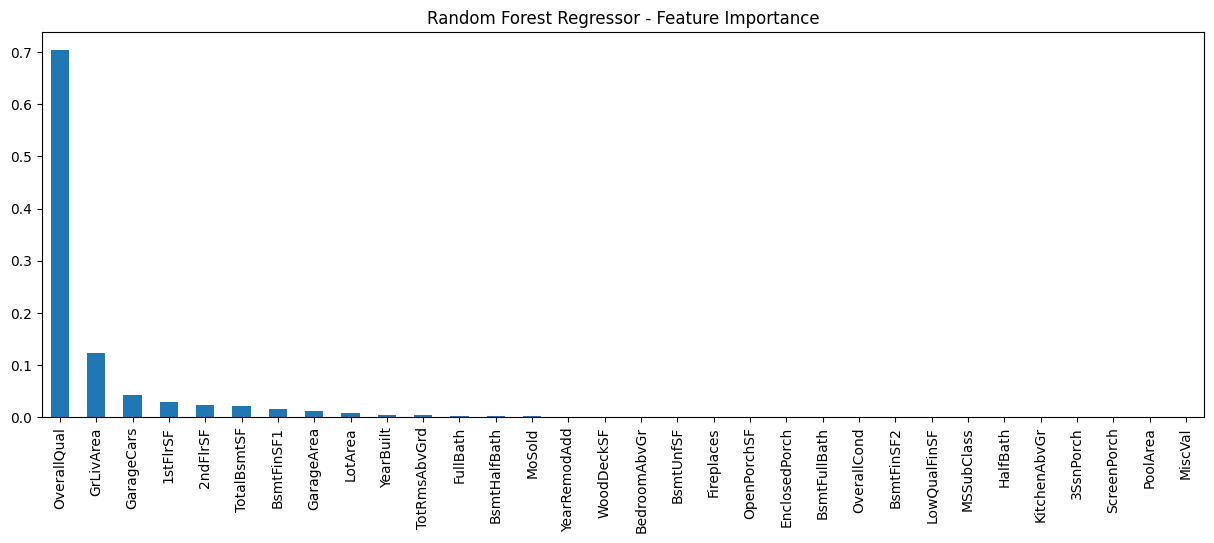

In [11]:
## plot RF model feature importance
pd.Series(
    rf.feature_importances_,
    index=rf.feature_names_in_,
).sort_values(
    ascending=False).plot.bar(figsize=(15, 5))

plt.title("Random Forest Regressor - Feature Importance")
plt.show();

### Summary
- We can say that the most valuable feature based on our model is the Overall quality of a house which is not surprising.

# Permutation Feature Importance

## Sklearn
- Below we can measure PFI using sklearn built-in function `permutation_importance`.
- We will use the **test set**. We do not want to use the **train set** because if our model is overfit to the trainin data it will not give us an accurate feature importance on unseen data thus we use the hold out or test set.
- Metric for PFI:
  - We can choose the metric to evaluate PFI on, in this case we can use the same metric from above the r2 value.
  - We dont have to use r2 but for simplicity we will use the same metric on the model trained above.

- `n_repeats`
  - This is the number of times that sklearn is going to shuffle the features in the test_set and obtain the average (PFI).
  - Note: the higher the number, the longer computation time you will need.

In [12]:
## run permutation_importance -- returns a dict
r = permutation_importance(
    rf,
    X_test, # we use the test set
    y_test,
    scoring= "r2", # we can use any metric
    n_repeats=5, ## num of times to shuffle data
    random_state=0,
)

In [13]:
# contains is an array of arrays
# contains the individual importance of each repetition#
# and the mean and std

## we can access the key-value pairs of the dict into a df
importance = pd.DataFrame(
    {"importance_mean": r["importances_mean"],
     "importance_std": r["importances_std"]},
    index=rf.feature_names_in_)

importance.head()

,importance_mean,importance_std
MSSubClass,0.000000,0.000000
LotArea,0.002312,0.001113
OverallQual,0.732075,0.045539
OverallCond,0.000000,0.000000
YearBuilt,0.002814,0.000494


### Summary
- The avg/mean is most commonly used.
- The std is used to help us with "gating" and deciding which features might be "borderline" and should be removed from the model or not.

### PFI
- Now we can visualize the PFI
- The larger the drop == more important the feature!

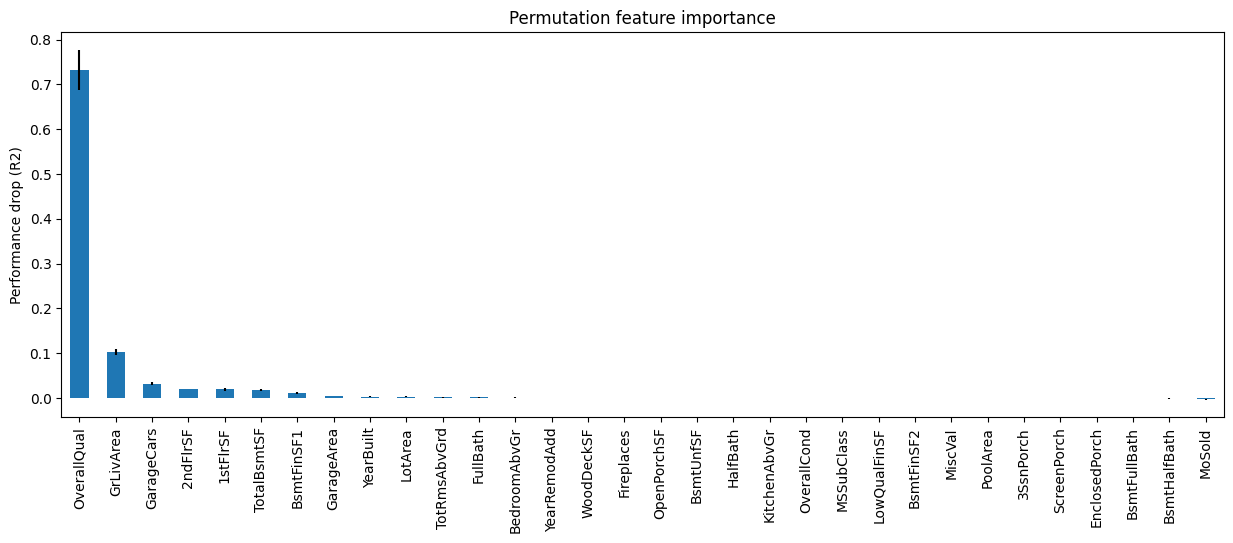

In [14]:
# The larger the drop, the more important the feature

importance["importance_mean"].sort_values(
    ascending=False
).plot(figsize=(15, 5), kind="bar", yerr=importance["importance_std"])

plt.title("Permutation feature importance")
plt.ylabel("Performance drop (R2)")
plt.show();

### Summary
- Not a surpise, no real change from the Random Forest Decision Trees feature importance values at all.
- Sklearn however only allows you to use PFI to evaluate how the features interact with the model but you can't use it additionally for feature selection. That is where the Python libraries below such as Eli5 come on.

# Eli5
- docs: https://eli5.readthedocs.io/en/latest/blackbox/permutation_importance.html
- This can help us determine feature importance with permutation.
- ELI5 differs from scikit-learn (sklearn) primarily in how it computes importance and how it visualizes the results.
  - While scikit-learn relies heavily on built-in, model-specific metrics (like Gini importance for trees), ELI5 focuses on cross-framework consistency, global and local explanations, and cleaner visual reporting.

## Eli5 - Calculation Mechanics: MDI vs. Permutation
- scikit-learn:
  - When you call model.feature_importances_ on a tree-based model, it uses Mean Decrease in Impurity (MDI).
  - This calculates how much each feature's splits reduce node impurity during training.
  - Because it is calculated purely on the training data, it doesn't always reflect how important a feature is for generalization on unseen data.
  
- ELI5:
  - It popularised the use of Permutation Importance.
  - It takes a trained model and a validation dataset, shuffles the values of a single feature, and measures how much the model's score drops.
  - If shuffling a feature breaks the score, that feature is highly important.


### Local vs. Global Explanations
- scikit-learn:
  - tells you how the model works overall (globally).
  - It will not natively tell you why the model gave a specific prediction for row #42.

- ELI5:
  - This excels at local explanations. - Using functions like explain_prediction(), it breaks down exactly which features pushed a specific, single row's prediction higher or lower.

### Install eli5
- need to install eli5 if you haven't already.

In [16]:
!pip install eli5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 3.5 MB/s eta 0:00:00


### Imports
- We import the specific eli5 PermutationImportance function and we will use the SelectFromModel from sklearn to help select features.

In [17]:
import eli5
from eli5.sklearn import PermutationImportance

from sklearn.feature_selection import SelectFromModel

### Setup and fit model

In [18]:
# set up the permutation class

# we already fit the estimator
perm = PermutationImportance(
    rf, ## fit model
    scoring="r2", ## metric to use
    n_iter=3,  # number of times each feature shuffled
    cv="prefit", ## we have a prefit model, if we didn't we would pass a diff param
    random_state=5, ## reproducibility
)

# Note that we use the test set to calculate
# the feature importance
### We are not really "fitting a model" -- we are shuffling the data 3 times
perm.fit(X_test, y_test)

perm

PermutationImportance(estimator=RandomForestRegressor(max_depth=3,
                                                      random_state=2909),
                      n_iter=3, random_state=5, scoring='r2')

### Obtain Feature Importances
- After shuffling we can now see the array of feature importances.

In [19]:
# the feature importance values

perm.feature_importances_

array([ 0.00000000e+00,  1.47401850e-03,  7.27795377e-01,  0.00000000e+00,
        3.25644815e-03,  4.22686595e-04,  9.61795188e-03,  0.00000000e+00,
        1.28173176e-04,  1.93883863e-02,  2.06729441e-02,  1.93537779e-02,
        0.00000000e+00,  1.09235820e-01, -2.50279398e-04, -5.84272750e-05,
        9.45563236e-04,  0.00000000e+00,  3.41187614e-04,  0.00000000e+00,
        1.46430521e-03,  2.40334648e-04,  3.13425578e-02,  4.55091346e-03,
        1.21993271e-04,  3.89023130e-05, -3.33135605e-05,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -2.37228949e-03])

### Obtain Feature Importances std

In [20]:
# the standard deviation of the importance

perm.feature_importances_std_

array([0.00000000e+00, 6.08552417e-04, 3.58031596e-02, 0.00000000e+00,
       4.47035700e-04, 2.78212253e-04, 6.00368322e-04, 0.00000000e+00,
       1.64974899e-04, 2.74337893e-04, 4.52540098e-04, 4.93654437e-05,
       0.00000000e+00, 6.70822692e-03, 1.85154840e-04, 9.59564557e-04,
       1.00855052e-04, 0.00000000e+00, 5.44262212e-04, 0.00000000e+00,
       2.73203570e-04, 3.30558888e-05, 3.02395188e-04, 1.05952580e-03,
       1.28752987e-04, 2.66276421e-05, 1.10503821e-04, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 3.59446460e-04])

In [21]:
importance = pd.DataFrame({
    "importance": perm.feature_importances_,
    "std": perm.feature_importances_std_,
    },
    index = X_test.columns.to_list()
)

importance.head()

,importance,std
MSSubClass,0.000000,0.000000
LotArea,0.001474,0.000609
OverallQual,0.727795,0.035803
OverallCond,0.000000,0.000000
YearBuilt,0.003256,0.000447


### Plot feature importances from eli5

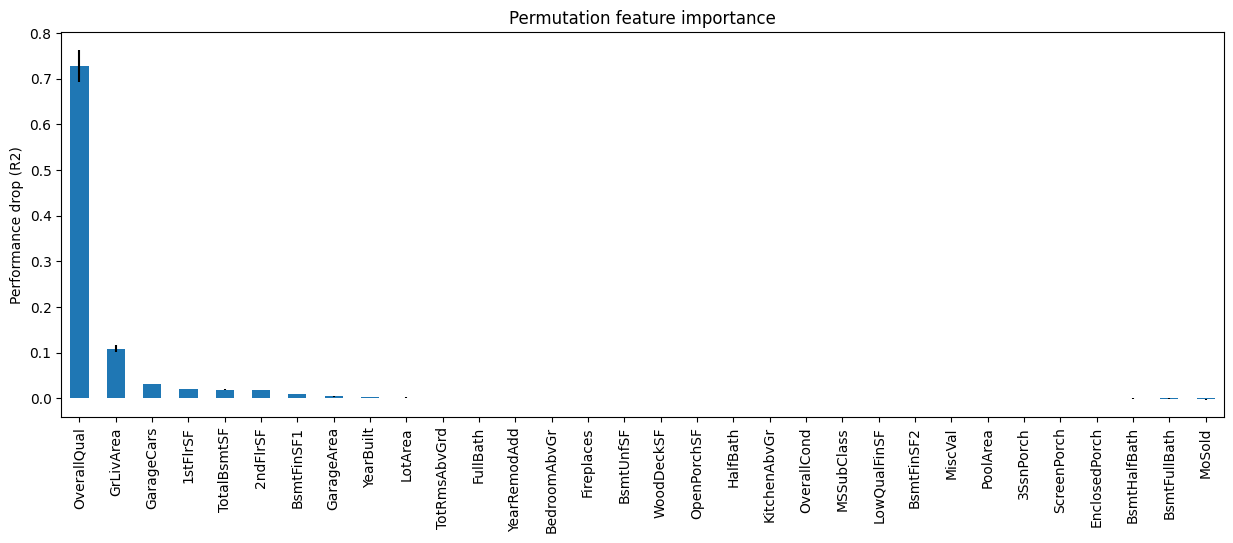

In [22]:
# plot manually

importance["importance"].sort_values(
    ascending=False
).plot(figsize=(15, 5), kind="bar", yerr=importance["std"])

plt.title("Permutation feature importance")
plt.ylabel("Performance drop (R2)")
plt.show();

### eli5 - show weights (Global Explanation)
- show weights will reveal which features or internal weights are most important to the model

In [23]:
# with eli5 -- gives us the weights

eli5.show_weights(perm)

Weight,Feature
0.7278 ± 0.0716,x2
0.1092 ± 0.0134,x13
0.0313 ± 0.0006,x22
0.0207 ± 0.0009,x10
0.0194 ± 0.0005,x9
0.0194 ± 0.0001,x11
0.0096 ± 0.0012,x6
0.0046 ± 0.0021,x23
0.0033 ± 0.0009,x4
0.0015 ± 0.0012,x1


### Feature Selection

In [24]:
sel = SelectFromModel(
    perm, ## pass perm importance from eli5
    threshold=0.01, # select features above this threshold value
    prefit=True,
).set_output(transform="pandas")

# remove features
X_train_t = sel.transform(X_train)
X_test_t = sel.transform(X_test)

X_train_t.shape

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


(1022, 6)

In [25]:
# Resulting dataframe

X_train_t.head()

,OverallQual,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,GarageCars
64,7,1057,1057,977,2034,2
682,6,1291,1291,0,1291,2
960,5,858,858,0,858,0
1384,6,560,698,560,1258,1
1100,2,290,438,0,438,1


# Feature-engine
- this is another library we can use similar to eli5
- read docs: https://feature-engine.trainindata.com/en/latest/quickstart/index.html

## Install feature-engine

In [27]:
!pip install feature-engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 2.2 MB/s eta 0:00:00


In [28]:
from feature_engine.selection import SelectByShuffling

In [29]:
sel = SelectByShuffling(
    variables=None, # automatically examine all numerical variables
    estimator=rf, # the ML model
    scoring='r2', # the metric to evaluate
    threshold=0.01,# the maximum performance drop allowed to select the feature
    cv=3, # cross-validation
    random_state=1 # seed
)

# Feature-engine measures importance with
# cross-validation over the train set
# the importance is derived from the
# held out fold

sel.fit(X_train, y_train)

SelectByShuffling(estimator=RandomForestRegressor(max_depth=3,
                                                  random_state=2909),
                  random_state=1, scoring='r2', threshold=0.01)

### Full model performance -- without shuffling features

In [30]:
# full model performance

sel.initial_model_performance_

np.float64(0.7581387528793667)

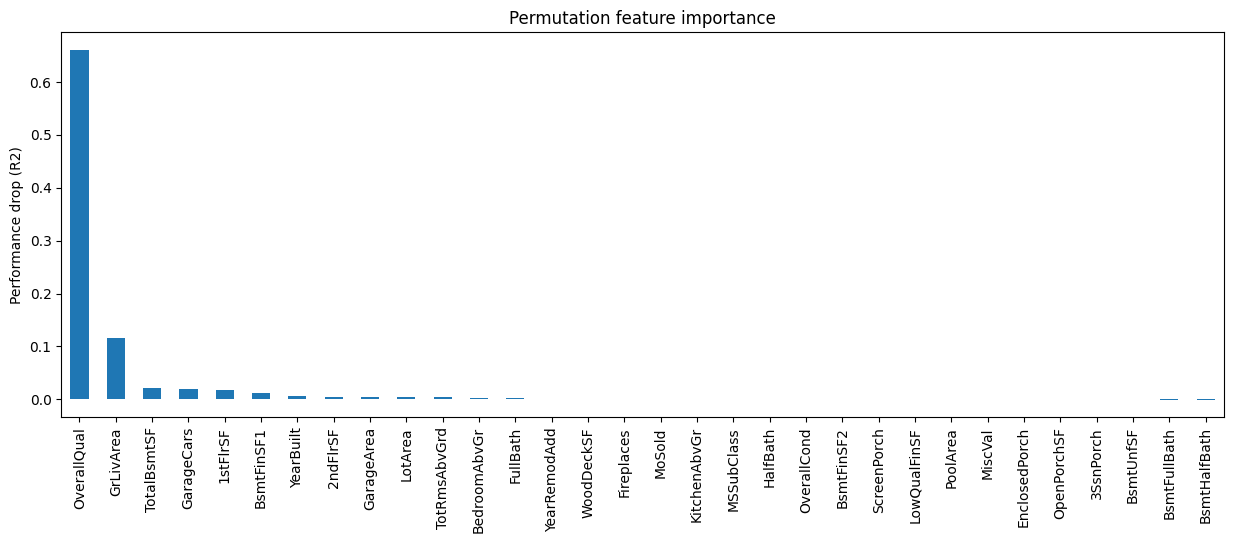

In [31]:
pd.Series(sel.performance_drifts_).sort_values(
    ascending=False).plot.bar(figsize=(15, 5))

plt.title("Permutation feature importance")
plt.ylabel("Performance drop (R2)")
plt.show()

### Summary
- For now it outputs only the mean.
- We can see the result is very similar to the original RF model features, the sklearn, and the eli5 feature importances.

In [32]:
# Drop features (select features)

X_train_t = sel.transform(X_train)
X_test_t = sel.transform(X_test)

X_train_t.shape

(1022, 6)

In [33]:
X_train_t.head()

,OverallQual,BsmtFinSF1,TotalBsmtSF,1stFlrSF,GrLivArea,GarageCars
64,7,739,1057,1057,2034,2
682,6,1003,1291,1291,1291,2
960,5,696,858,858,858,0
1384,6,204,560,698,1258,1
1100,2,290,290,438,438,1


# Considerations

## 1. Train vs. Test sets
- PFI should be calculated using the TEST set or a held out sample -- always shuffle on the TEST set!!!!!!!!!
- This is because if the original trained model was overfit to the training data, then the feature importance will be meaningless.
- **This is why using the TEST set to derive feature importance is paramount as it allows us to see how the model generalizes on unseen data.**
  - **In other words it tells us how the model performs on unseen data in regards to what features are most important as predicted by our model.**


## 2. Feature Importance Values
- Aggregated importance of every feature is GREATER than DROP in performance when we shuffle ALL features.
  - This means we take for example:
    - perf drop shuffle #1 + perf drop shuffle #2 + perf drop shuffle #3 = value may be greater than drop in performance of all features.
    - In other words not all features are additive.
- Shuffling is COSTLY!!!
  - This is because it costs time and compute to continually shuffle the test set.
  - The more features == more costly!

- RANDOMNESS
  - When feature is borderline important this comes into play.


## 3. Susceptible to Correlation
- **Reduced individual importance results when**:
  - features are correlated with one another --> this causes their importance to be distributed which reduces the weight of importance for each feature individually
  - This is similar to multi-collinearity in linear regression. However, for multi-collinearity it is usually 3 or more features and we measure the VIF (variance inflation factor). Feature correlation is usually a pairwse measurement.

- **Decreased importance can actually indicate correlation instead of a significant feature**.
  - This is something to keep in mind.


## 4. Recursive Elimination
- This can help us reduce the increased likelihood of correlation interfering with the results.
- To do this we would:
  - Combine permutation feature importance with recursive elimination
  - This involves removing a feature that is highly correlated so we can closely investigate a features importance to the rest of the data. This often comes at the cost of computation increases (have to retrain the model each time we recursively eliminate features).
- This is very closely related to ablation testing.